<a href="https://colab.research.google.com/github/ChitrashreeShankaranandha/AgenticAI_LLMs_RAG/blob/main/Travel_Recommendation_LangGraph_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement**

This is a LangGraph based recommendation system / agent for suggesting travel destinations based on desired activities

**Example-**

 "user_input": "I want a relaxing beach vacation"

 Agent response:

 🌍 Suggested destination: Bali

  🔧 itinerary_agent running…


🧳 Draft itinerary:

Day 1: Arrive in Bali

Day 2: Explore iconic spots in Bali

Day 3: Relax + sample local cuisine


🔧 activity_agent running…

🎯 Suggested activities: Snorkelling • Beach yoga


In [ ]:
!pip install -q --upgrade langgraph langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.5/167.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 10.6 MB/s eta 0:00:00


In [ ]:
from typing import TypedDict

class TravelState(TypedDict, total=False):
    user_input: str          # raw question
    destination: str         # “Bali”, “Manali”, …
    itinerary: str           # multi-day plan
    activities: str          # granular activities

In [ ]:
def destination_node(state: TravelState) -> TravelState:
    """ LangGraph node for destination agent """
    print("🔧 destination_agent running…")

    q = state.get("user_input", "").lower()
    # LLM call to parse the information in q, and make decisions
    # API calls

    if "beach" in q:
        dest = "Bali"
    elif "snow" in q or "mountain" in q:
        dest = "Manali"
    elif "city" in q:
        dest = "LA"
    else:
        dest = "Kyoto"  # sensible default

    print(f"🌍 Suggested destination: {dest}")
    return {**state, "destination": dest}

In [ ]:
def itinerary_node(state: TravelState) -> TravelState:
    """ LangGraph node for itinerary agent """
    print("🔧 itinerary_agent running…")
    dest = state["destination"]
    plan = (
        f"Day 1: Arrive in {dest}\n"
        f"Day 2: Explore iconic spots in {dest}\n"
        f"Day 3: Relax + sample local cuisine"
    )
    print(f"🧳 Draft itinerary:\n{plan}")
    return {**state, "itinerary": plan}

In [ ]:
def activity_node(state: TravelState) -> TravelState:
    """ LangGraph node for activity agent """
    print("🔧 activity_agent running…")
    dest = state["destination"]
    act = (
        "Snorkelling • Beach yoga"
        if dest == "Bali"
        else "Skiing • Mountain trek"
    )
    print(f"🎯 Suggested activities: {act}")
    return {**state, "activities": act}

In [ ]:
from langgraph.graph import StateGraph

builder = StateGraph(TravelState)

builder.add_node("destination_agent", destination_node)
builder.add_node("itinerary_agent", itinerary_node)
builder.add_node("activity_agent", activity_node)

builder.set_entry_point("destination_agent")
builder.add_edge("destination_agent", "itinerary_agent")
builder.add_edge("itinerary_agent", "activity_agent")
builder.set_finish_point("activity_agent")

travel_graph = builder.compile()
print("✅ Graph compiled.")

✅ Graph compiled.


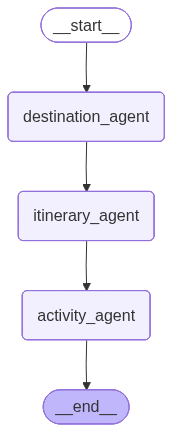

In [ ]:
from IPython.display import Image, display

display(Image(travel_graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state: TravelState = {
    "user_input": "I want a relaxing beach vacation"
}

final_state = travel_graph.invoke(initial_state)

print("\n🏁 Final state:")
for k, v in final_state.items():
    print(f"{k}: {v}")

🔧 destination_agent running…
🌍 Suggested destination: Bali
🔧 itinerary_agent running…
🧳 Draft itinerary:
Day 1: Arrive in Bali
Day 2: Explore iconic spots in Bali
Day 3: Relax + sample local cuisine
🔧 activity_agent running…
🎯 Suggested activities: Snorkelling • Beach yoga

🏁 Final state:
user_input: I want a relaxing beach vacation
destination: Bali
itinerary: Day 1: Arrive in Bali
Day 2: Explore iconic spots in Bali
Day 3: Relax + sample local cuisine
activities: Snorkelling • Beach yoga


In [ ]:
initial_state: TravelState = {
    "user_input": "I want a snowy mountain trip"
}
final_state = travel_graph.invoke(initial_state)

print("\n🏁 Final state:")
for k, v in final_state.items():
    print(f"{k}: {v}")

🔧 destination_agent running…
🌍 Suggested destination: Manali
🔧 itinerary_agent running…
🧳 Draft itinerary:
Day 1: Arrive in Manali
Day 2: Explore iconic spots in Manali
Day 3: Relax + sample local cuisine
🔧 activity_agent running…
🎯 Suggested activities: Skiing • Mountain trek

🏁 Final state:
user_input: I want a snowy mountain trip
destination: Manali
itinerary: Day 1: Arrive in Manali
Day 2: Explore iconic spots in Manali
Day 3: Relax + sample local cuisine
activities: Skiing • Mountain trek


In [ ]:
initial_state: TravelState = {
    "user_input": "I want a city tour"
}
final_state = travel_graph.invoke(initial_state)

print("\n Final state:")
for k,v in final_state.items():
  print(f"{k}: {v}")

🔧 destination_agent running…
🌍 Suggested destination: LA
🔧 itinerary_agent running…
🧳 Draft itinerary:
Day 1: Arrive in LA
Day 2: Explore iconic spots in LA
Day 3: Relax + sample local cuisine
🔧 activity_agent running…
🎯 Suggested activities: Skiing • Mountain trek

 Final state:
user_input: I want a city tour
destination: LA
itinerary: Day 1: Arrive in LA
Day 2: Explore iconic spots in LA
Day 3: Relax + sample local cuisine
activities: Skiing • Mountain trek
